# **Importando a base**

Base utilizada: base analítica previamente tratada no SQL, após aplicação dos critérios definidos para tratamento de valores extremos.

In [ ]:
import pandas as pd
import urllib.request

url = "https://github.com/luizamb2306/analise_performance_varejista/raw/refs/heads/main/base_python.csv"

urllib.request.urlretrieve(url, "base_python.csv")

dados = pd.read_csv("base_python.csv")

print(dados)

          vendas  descontos  venda_líquida  qtd_unidades    lucro  \
0     10123.0200       0.07     9414.40860            49   457.81   
1       244.5700       0.01      242.12430            27    46.71   
2      4965.7595       0.08     4568.49874            30  1198.97   
3       146.6900       0.05      139.35550            21     4.43   
4       394.2700       0.08      362.72840            19    30.94   
...          ...        ...            ...           ...      ...   
7287  10071.0900       0.10     9063.98100            41  1977.69   
7288    392.5700       0.04      376.86720            23    22.25   
7289    823.7800       0.03      799.06660            37   343.05   
7290    469.8375       0.00      469.83750             8  -159.24   
7291   2026.0100       0.10     1823.40900            20   580.43   

      custo_entrega  custo_implicito prioridades_pedidos categorias_produto  \
0             68.02       8888.57860                HIGH    OFFICE SUPPLIES   
1            

# **EDA Univariada**

**Dados qualitativos**

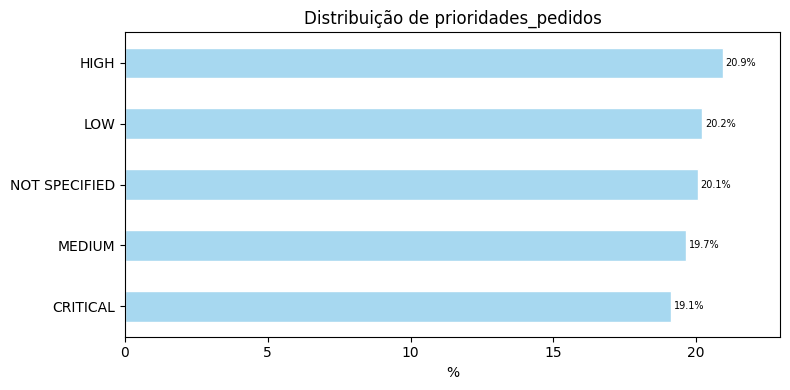

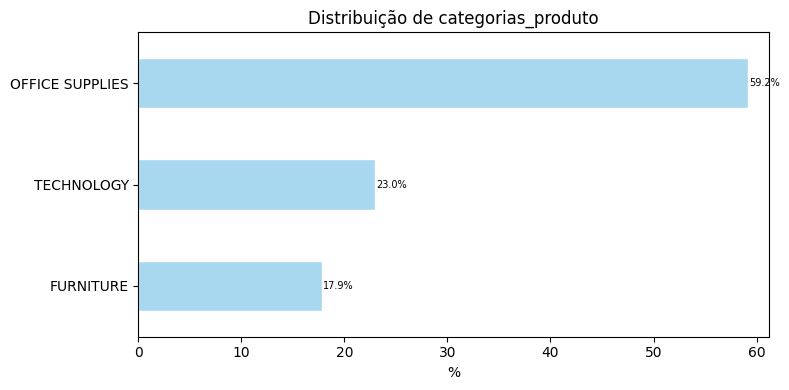

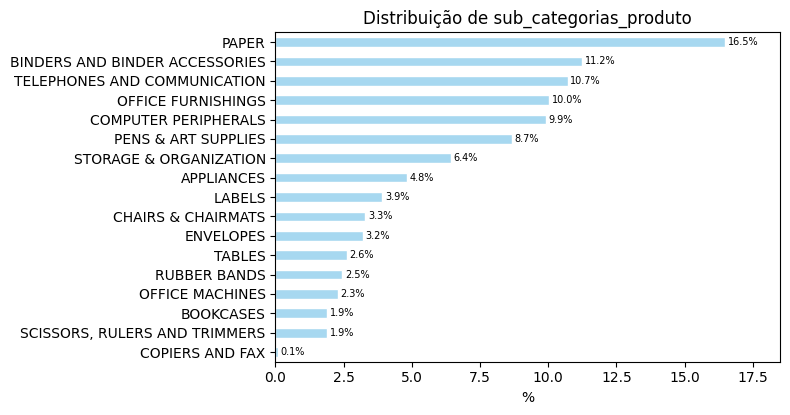

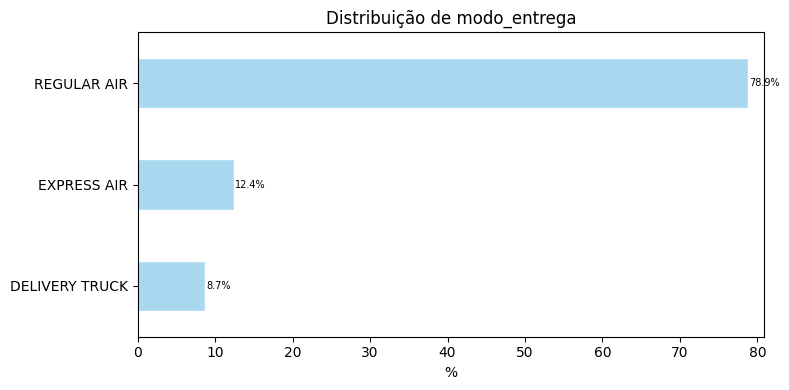

In [ ]:
import matplotlib.pyplot as plt

# dados de interesse
quali = ['prioridades_pedidos','categorias_produto', 'sub_categorias_produto', 'modo_entrega' ]


def eda_qualitativos(df, coluna):
    freq = df[coluna].value_counts() / len(df) * 100
    return freq

for coluna in quali:

    analise = eda_qualitativos(dados, coluna)

    analise = analise.sort_values()

    # define a altura do gráfico de acordo com a quantidade de categorias
    altura = len(analise) * 0.25

    if altura < 4:
        altura = 4

    plt.figure(figsize=(8, altura))

    ax = analise.plot(
        kind='barh',
        color='#A7D8F0',
        edgecolor='white'
    )

    plt.title(f'Distribuição de {coluna}')

    plt.xlabel('%')

    plt.ylabel('')

    plt.xlim(0, analise.max() + 2)

    for i, valor in enumerate(analise):

        plt.text(
            valor + 0.1,
            i,
            f'{valor:.1f}%',
            va='center',
            fontsize=7
        )

    plt.tight_layout()

    plt.show()

    plt.close()

**Dados quantitativos**

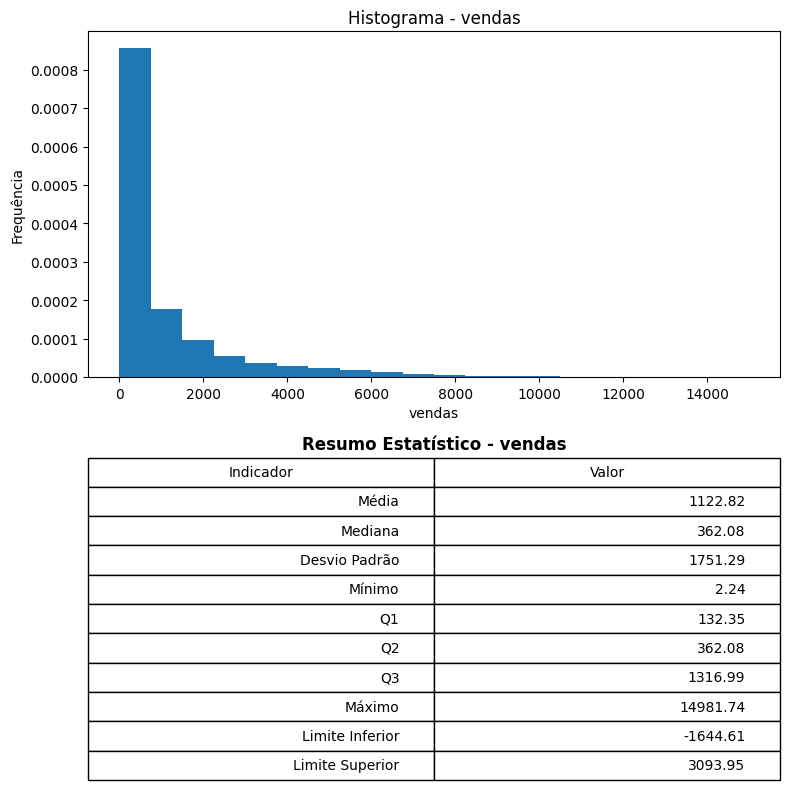

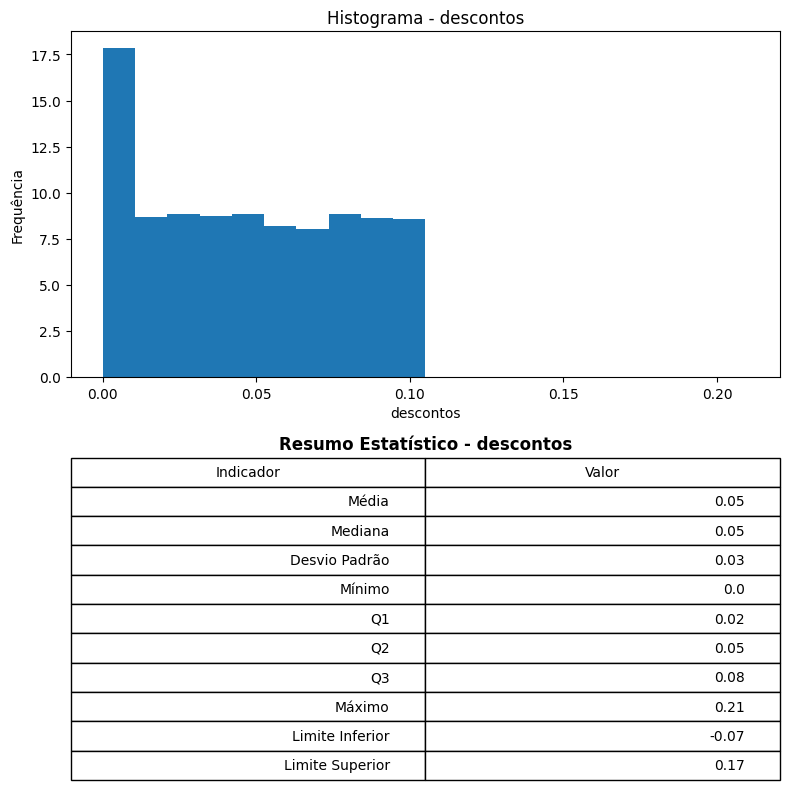

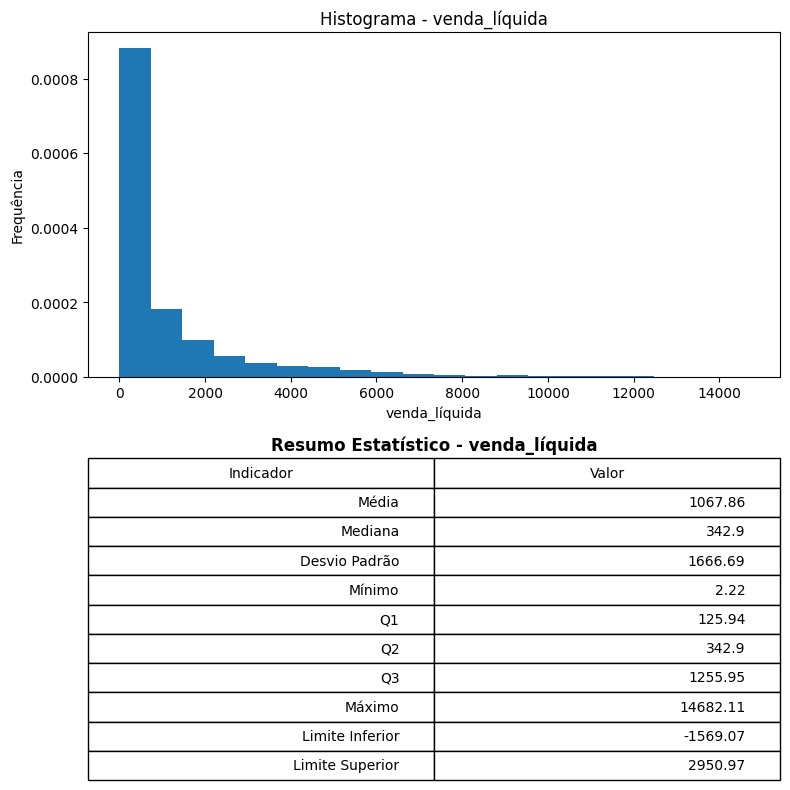

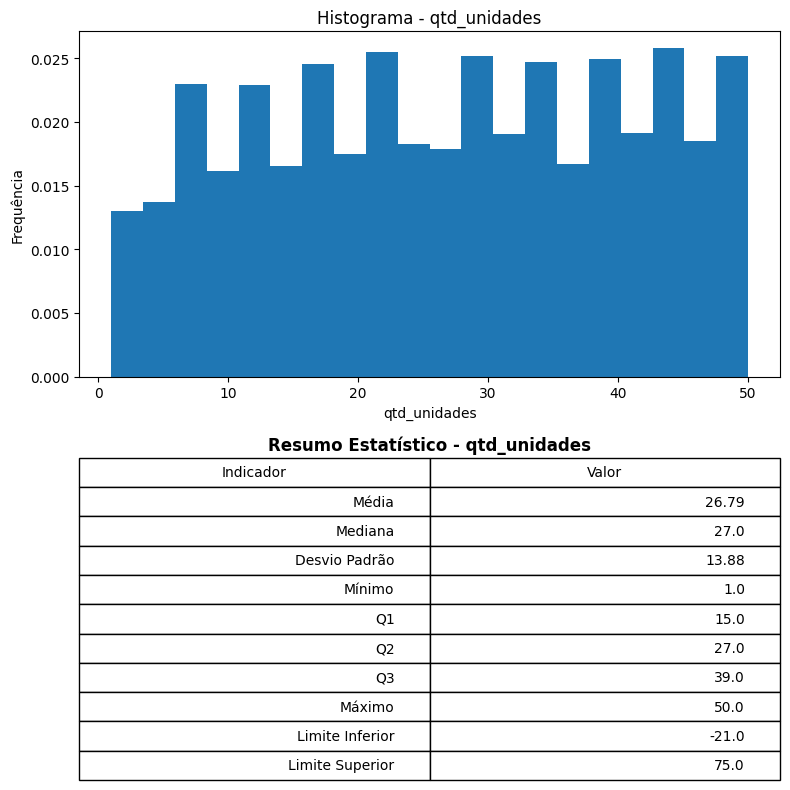

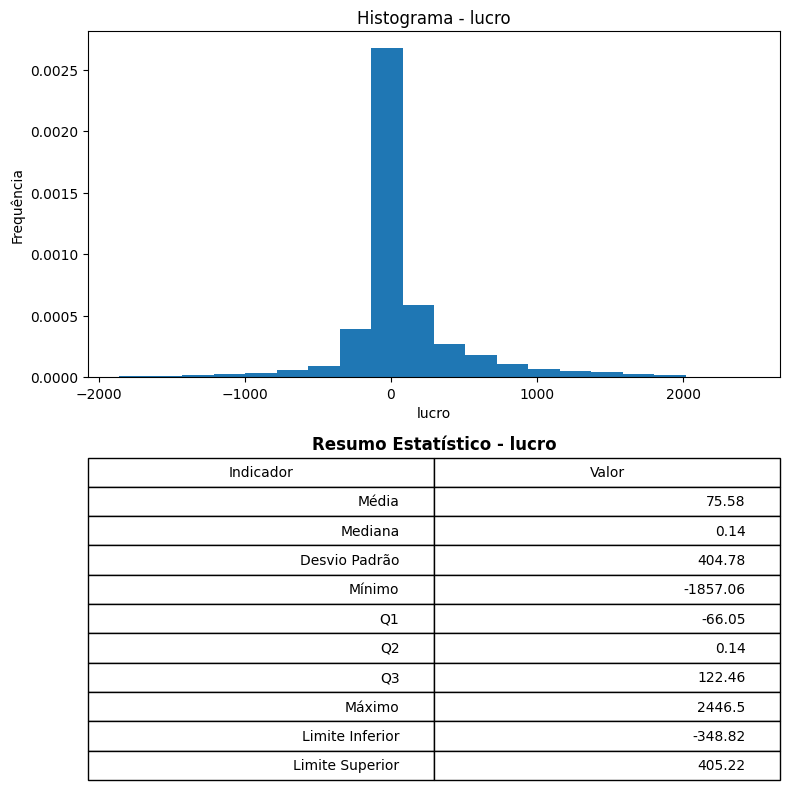

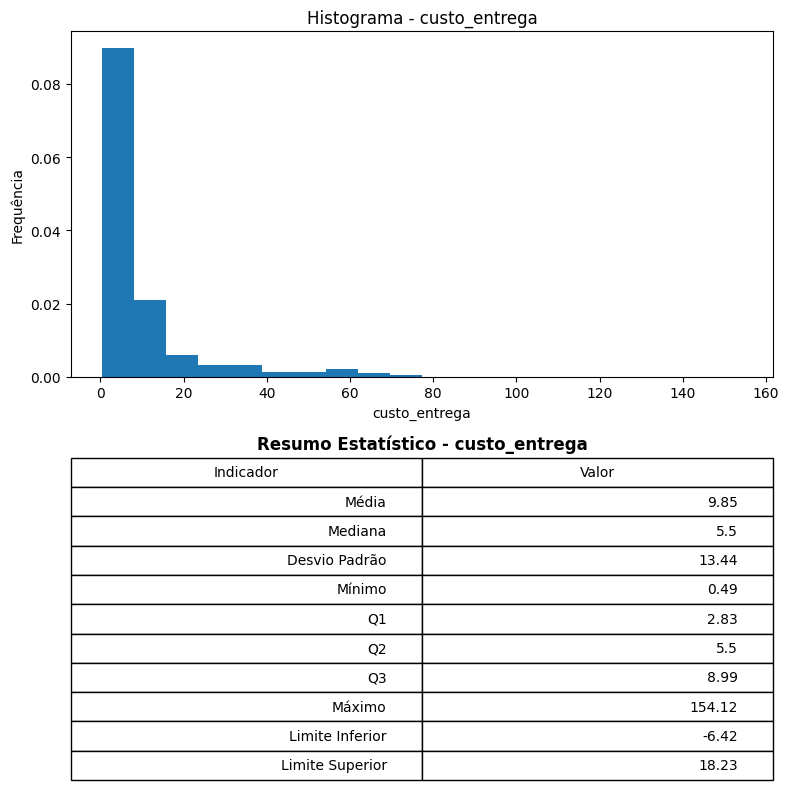

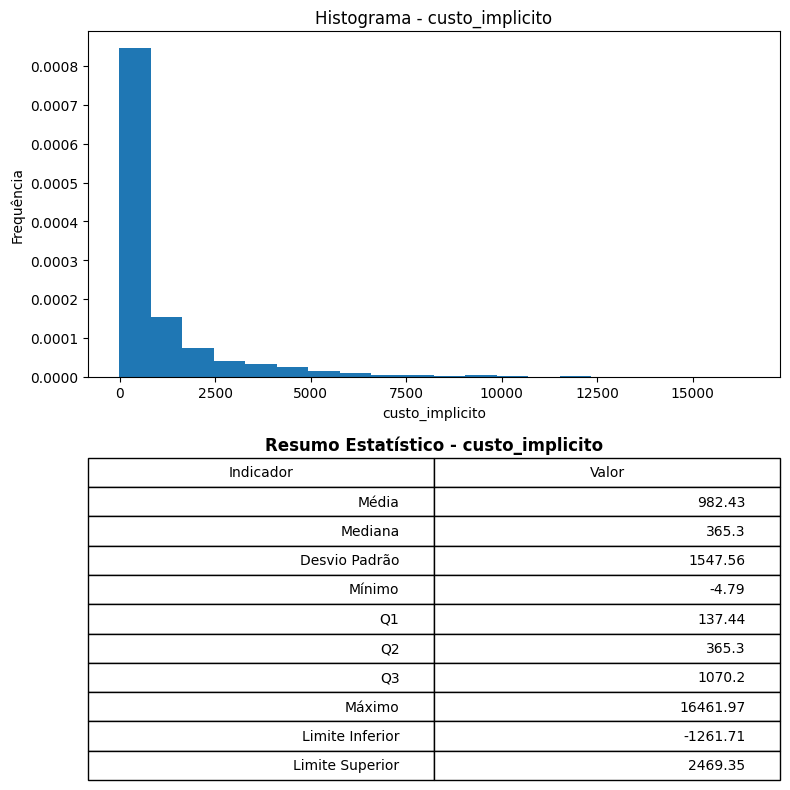

In [ ]:


quanti = ['vendas', 'descontos', 'venda_líquida', 'qtd_unidades', 'lucro', 'custo_entrega', 'custo_implicito']

def eda_quanti(df, coluna):

    media = df[coluna].mean()
    mediana = df[coluna].median()
    desvio = df[coluna].std()

    minimo = df[coluna].min()
    maximo = df[coluna].max()

    q1 = df[coluna].quantile(0.25)
    q2 = df[coluna].quantile(0.5)
    q3 = df[coluna].quantile(0.75)

    iqr = q3 - q1

    limite_inferior = q1 - (1.5 * iqr)
    limite_superior = q3 + (1.5 * iqr)

    # dicionário com resultados
    resumo = {
        'Média': media,
        'Mediana': mediana,
        'Desvio Padrão': desvio,
        'Mínimo': minimo,
        'Q1': q1,
        'Q2': q2,
        'Q3': q3,
        'Máximo': maximo,
        'Limite Inferior': limite_inferior,
        'Limite Superior': limite_superior
    }

    return resumo

for coluna in quanti:

  resumo = eda_quanti(dados, coluna)

  # FIGURA
  fig, ax = plt.subplots(
      2, 1,
      figsize=(8,8),
      gridspec_kw={'height_ratios': [2,1.8]}
  )

  # HISTOGRAMA

  ax[0].hist(
      dados[coluna].dropna(),
      bins=20,
      density = True
  )

  ax[0].set_title(f'Histograma - {coluna}')
  ax[0].set_xlabel(coluna)
  ax[0].set_ylabel('Frequência')

  # remove notação científica
  ax[0].ticklabel_format(style='plain', axis='x')

  # TABELA RESUMO

  tabela_resumo = pd.DataFrame(
      resumo.items(),
      columns=['Indicador', 'Valor']
  )

  # limita valores para 2 casas decimais
  tabela_resumo['Valor'] = tabela_resumo['Valor'].round(2)

  ax[1].axis('off')

  ax[1].set_title(
      f'Resumo Estatístico - {coluna}',
      fontsize=12,
      fontweight='bold',
      pad=10
  )

  tabela = ax[1].table(
      cellText=tabela_resumo.values,
      colLabels=tabela_resumo.columns,
      loc='center'
  )

  tabela.auto_set_font_size(False)
  tabela.set_fontsize(10)
  tabela.scale(1, 1.5)

  plt.tight_layout()

  plt.show()

  plt.close()


# **EDA Bivariada**

O objetivo desta análise é verificar se as variáveis quantitativas apresentam diferenças em sua distribuição entre as categorias da variável qualitativa de interesse. Para isso, são calculadas medidas descritivas para cada grupo, permitindo comparar o comportamento das variáveis entre as diferentes categorias.

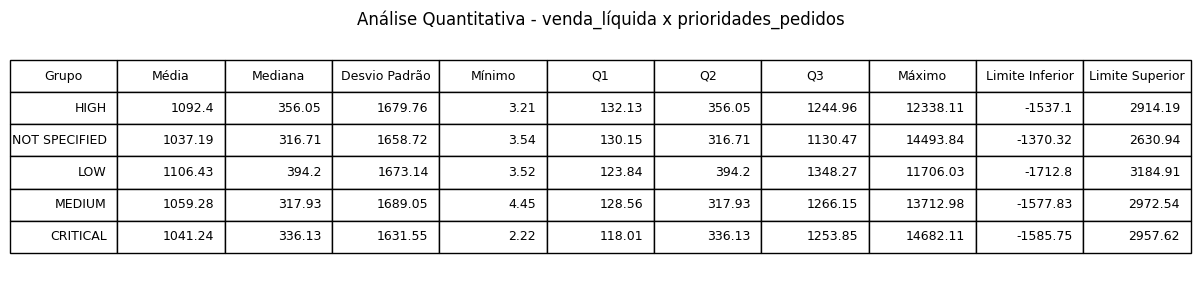

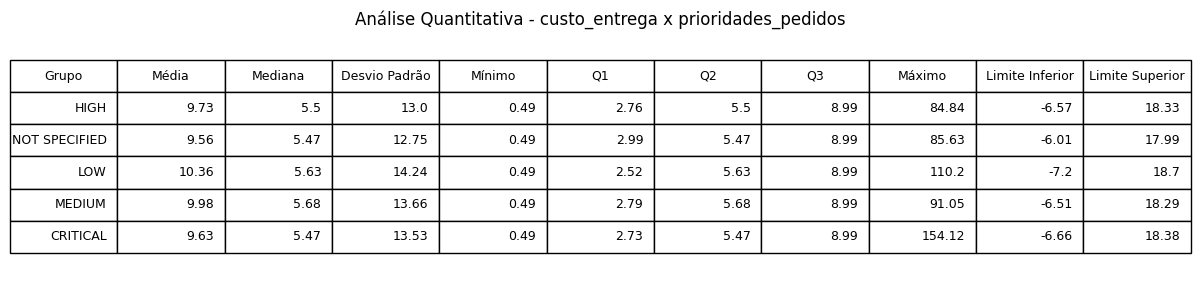

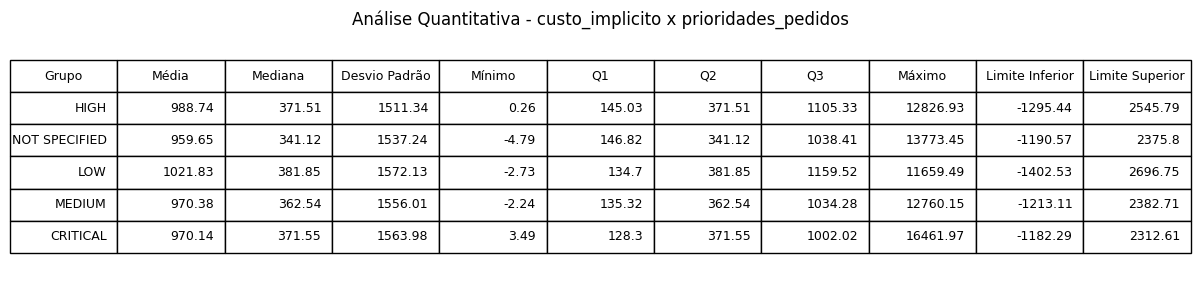

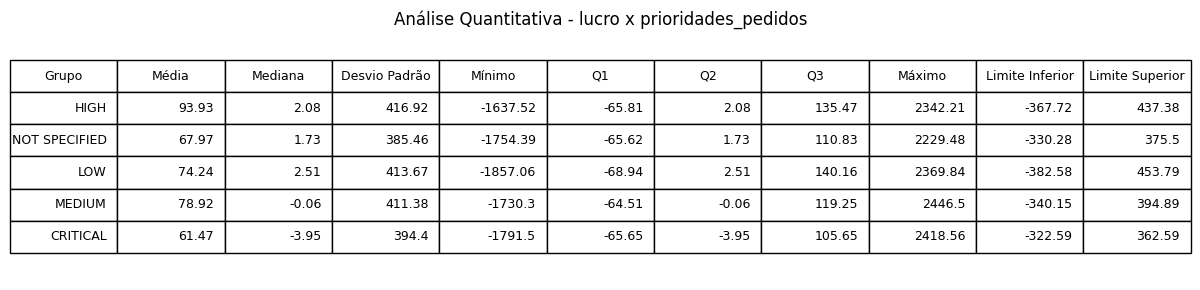

In [ ]:
import pandas as pd

target = 'prioridades_pedidos'

df = dados

quanti = ['venda_líquida', 'custo_entrega', 'custo_implicito', 'lucro']

# função resumo
def eda_quanti(df, coluna):

    media = df[coluna].mean()
    mediana = df[coluna].median()
    desvio = df[coluna].std()

    minimo = df[coluna].min()
    maximo = df[coluna].max()

    q1 = df[coluna].quantile(0.25)
    q2 = df[coluna].quantile(0.5)
    q3 = df[coluna].quantile(0.75)

    iqr = q3 - q1

    limite_inferior = q1 - (1.5 * iqr)
    limite_superior = q3 + (1.5 * iqr)

    resumo = {
        'Média': media,
        'Mediana': mediana,
        'Desvio Padrão': desvio,
        'Mínimo': minimo,
        'Q1': q1,
        'Q2': q2,
        'Q3': q3,
        'Máximo': maximo,
        'Limite Inferior': limite_inferior,
        'Limite Superior': limite_superior
    }

    return resumo

for coluna in quanti:

    resultados = []

    for grupo in df[target].unique():

        df_filtrado = df[df[target] == grupo]

        resumo = eda_quanti(df_filtrado, coluna)

        resumo['Grupo'] = grupo

        resultados.append(resumo)

    tabela_final = pd.DataFrame(resultados)

    tabela_final = tabela_final[
        [
            'Grupo',
            'Média',
            'Mediana',
            'Desvio Padrão',
            'Mínimo',
            'Q1',
            'Q2',
            'Q3',
            'Máximo',
            'Limite Inferior',
            'Limite Superior'
        ]
    ]

    tabela_final = tabela_final.round(2)

    # FIGURA

    fig, ax = plt.subplots(figsize=(12,3))

    ax.axis('off')

    plt.title(f'Análise Quantitativa - {coluna} x {target}')

    tabela = ax.table(
        cellText=tabela_final.values,
        colLabels=tabela_final.columns,
        loc='center'
    )

    tabela.auto_set_font_size(False)
    tabela.set_fontsize(9)
    tabela.scale(1.2, 1.8)

    plt.tight_layout()

    plt.show()

    plt.close()


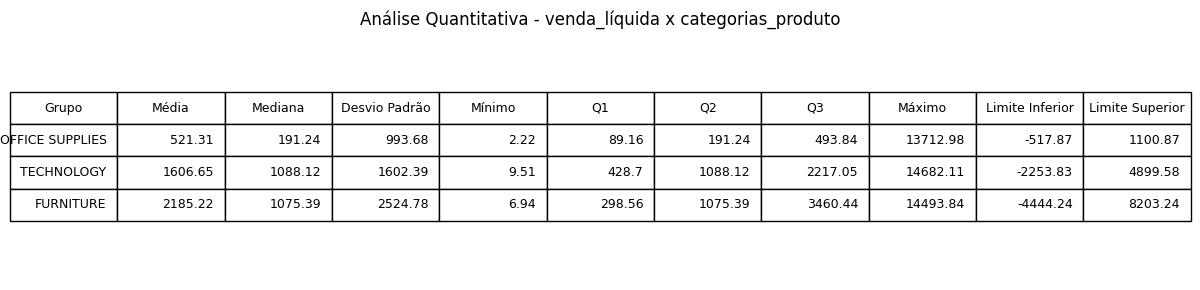

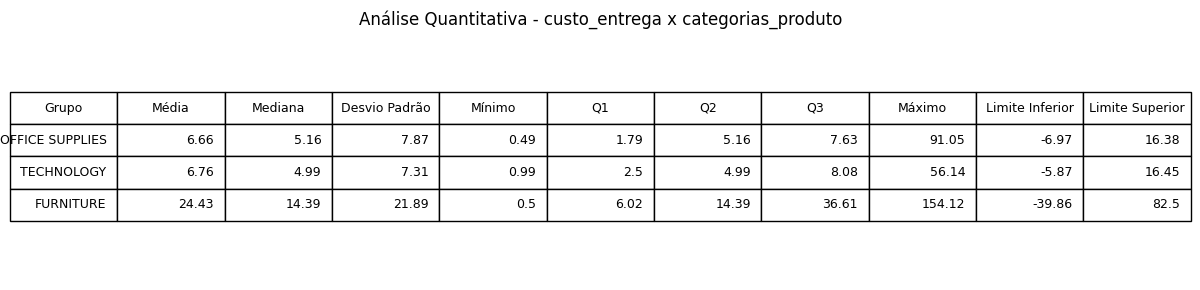

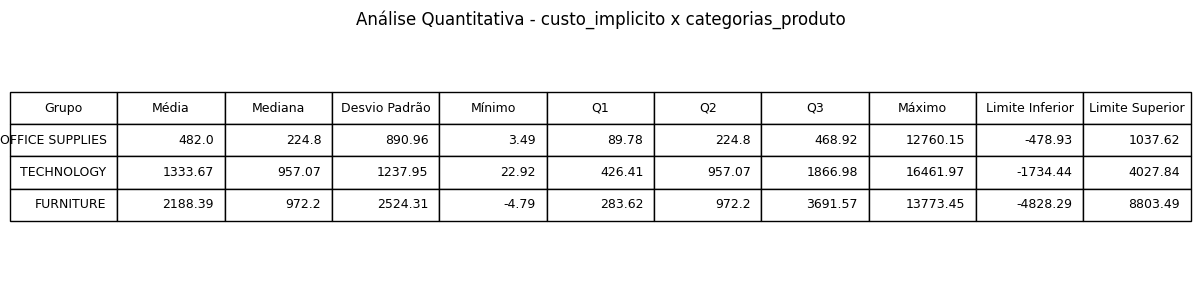

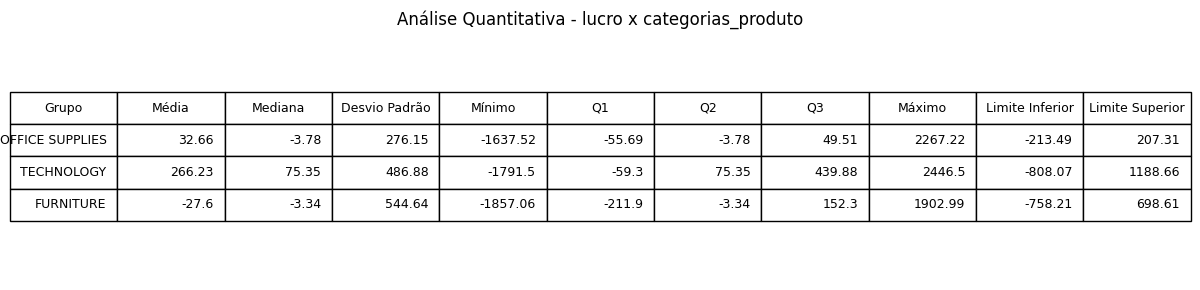

In [ ]:
import pandas as pd

target = 'categorias_produto'

df = dados

quanti = ['venda_líquida', 'custo_entrega', 'custo_implicito', 'lucro']

for coluna in quanti:

    resultados = []

    for grupo in df[target].unique():

        df_filtrado = df[df[target] == grupo]

        resumo = eda_quanti(df_filtrado, coluna)

        resumo['Grupo'] = grupo

        resultados.append(resumo)

    tabela_final = pd.DataFrame(resultados)

    tabela_final = tabela_final[
        [
            'Grupo',
            'Média',
            'Mediana',
            'Desvio Padrão',
            'Mínimo',
            'Q1',
            'Q2',
            'Q3',
            'Máximo',
            'Limite Inferior',
            'Limite Superior'
        ]
    ]

    tabela_final = tabela_final.round(2)

    # FIGURA

    fig, ax = plt.subplots(figsize=(12,3))

    ax.axis('off')

    plt.title(f'Análise Quantitativa - {coluna} x {target}')

    tabela = ax.table(
        cellText=tabela_final.values,
        colLabels=tabela_final.columns,
        loc='center'
    )

    tabela.auto_set_font_size(False)
    tabela.set_fontsize(9)
    tabela.scale(1.2, 1.8)

    plt.tight_layout()

    plt.show()

    plt.close()


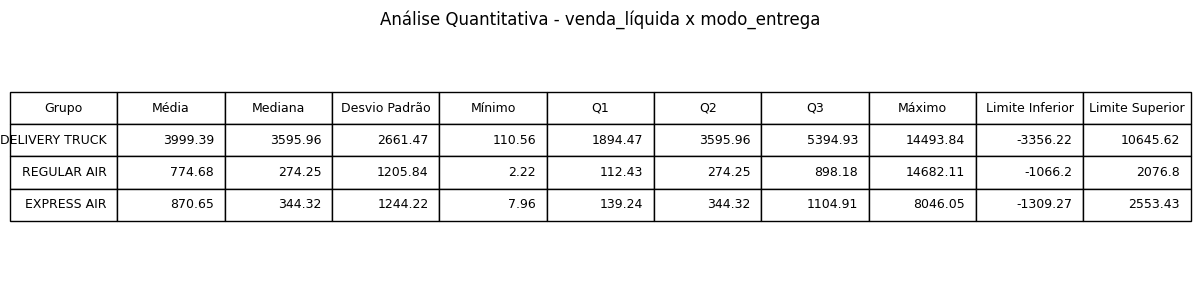

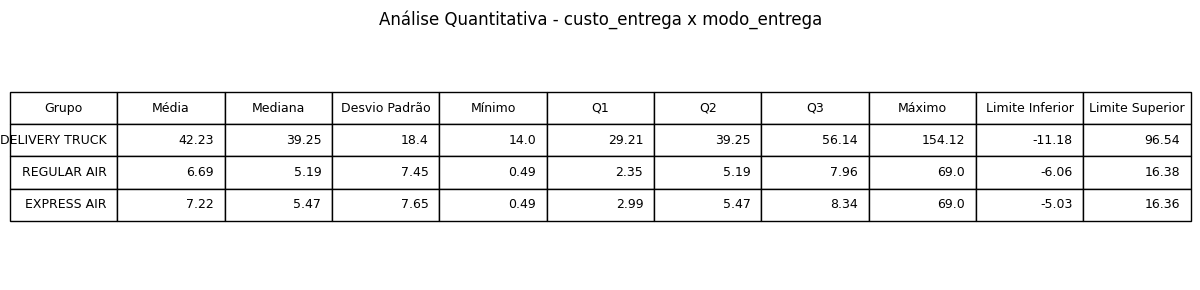

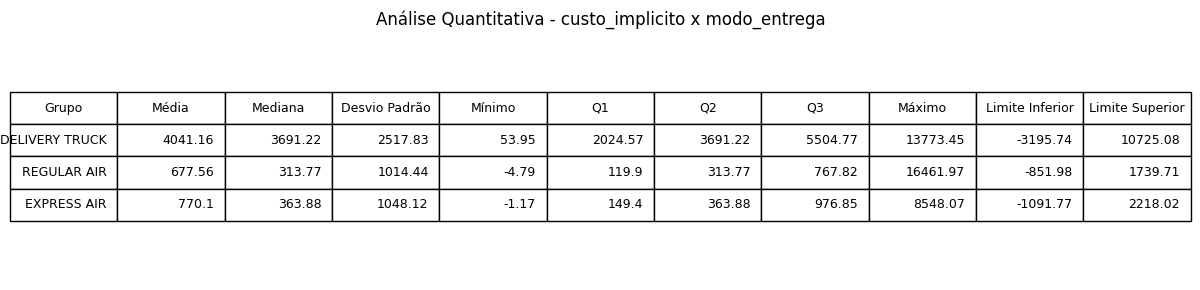

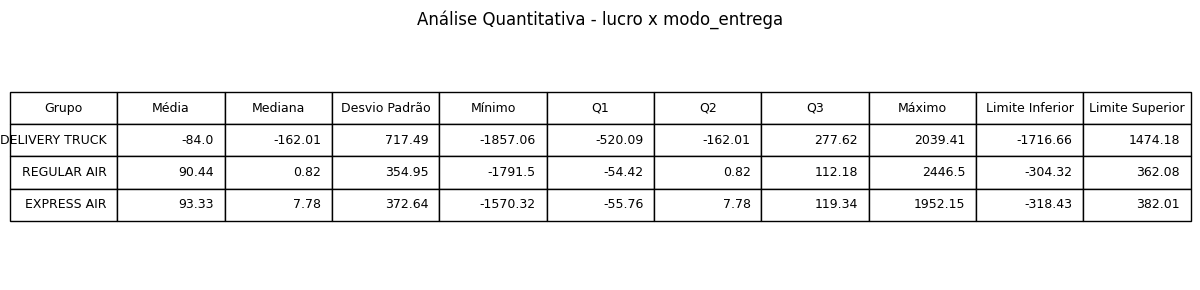

In [ ]:
import pandas as pd

target = 'modo_entrega'

df = dados

quanti = ['venda_líquida', 'custo_entrega', 'custo_implicito', 'lucro']

for coluna in quanti:

    resultados = []

    for grupo in df[target].unique():

        df_filtrado = df[df[target] == grupo]

        resumo = eda_quanti(df_filtrado, coluna)

        resumo['Grupo'] = grupo

        resultados.append(resumo)

    tabela_final = pd.DataFrame(resultados)

    tabela_final = tabela_final[
        [
            'Grupo',
            'Média',
            'Mediana',
            'Desvio Padrão',
            'Mínimo',
            'Q1',
            'Q2',
            'Q3',
            'Máximo',
            'Limite Inferior',
            'Limite Superior'
        ]
    ]

    tabela_final = tabela_final.round(2)

    # FIGURA

    fig, ax = plt.subplots(figsize=(12,3))

    ax.axis('off')

    plt.title(f'Análise Quantitativa - {coluna} x {target}')

    tabela = ax.table(
        cellText=tabela_final.values,
        colLabels=tabela_final.columns,
        loc='center'
    )

    tabela.auto_set_font_size(False)
    tabela.set_fontsize(9)
    tabela.scale(1.2, 1.8)

    plt.tight_layout()

    plt.show()

    plt.close()


**Agora, calculando o coeficiente de determinação**

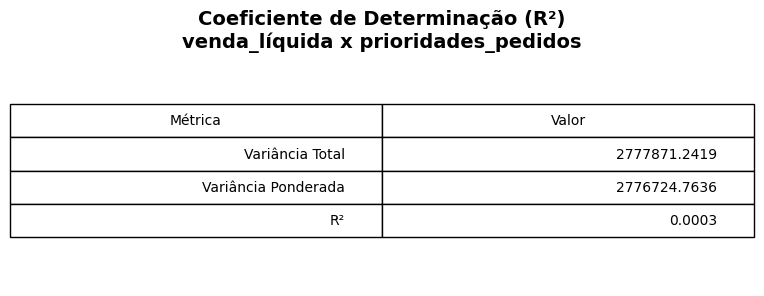

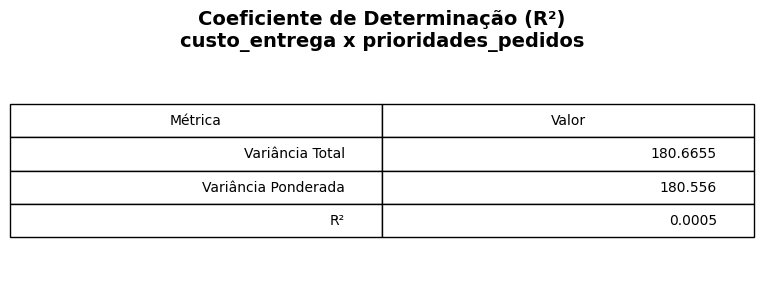

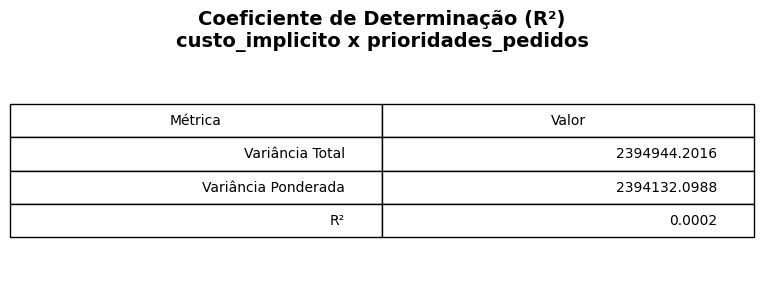

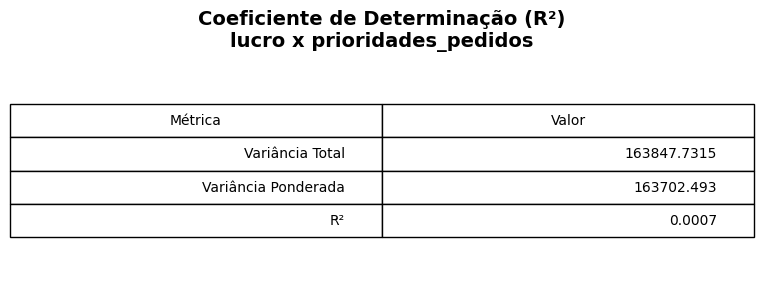

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

x = 'prioridades_pedidos'

quanti =  ['venda_líquida', 'custo_entrega', 'custo_implicito', 'lucro']

df = dados

def coef_determinacao(df, qualitativa, quantitativa):

    dados = df[[qualitativa, quantitativa]].dropna()

    media_geral = dados[quantitativa].mean()

    # Soma total dos quadrados
    SST = (
        (dados[quantitativa] - media_geral) ** 2
    ).sum()

    # Soma dos quadrados dentro dos grupos
    medias_grupos = (
        dados.groupby(qualitativa)[quantitativa]
        .transform('mean')
    )

    SSW = (
        (dados[quantitativa] - medias_grupos) ** 2
    ).sum()

    # R² / Eta²
    r2 = 1 - (SSW / SST)

    # Variância total
    var_total = dados[quantitativa].var()

    # Variância intra-grupos equivalente
    var_ponderada = SSW / len(dados)

    return r2, var_total, var_ponderada

for y in quanti:


    resultado = coef_determinacao(df, x, y)

    r2 = resultado[0]
    var_total = resultado[1]
    var_ponderada = resultado[2]

    tabela = pd.DataFrame({
        'Métrica': [
            'Variância Total',
            'Variância Ponderada',
            'R²'
        ],
        'Valor': [
            round(var_total, 4),
            round(var_ponderada, 4),
            round(r2, 4)
        ]
    })

    fig, ax = plt.subplots(figsize=(8, 3))

    ax.axis('off')

    ax.set_title(
        f'Coeficiente de Determinação (R²)\n{y} x {x}',
        fontsize=14,
        fontweight='bold'
    )

    tabela_plot = ax.table(
        cellText=tabela.values,
        colLabels=tabela.columns,
        loc='center'
    )

    tabela_plot.auto_set_font_size(False)
    tabela_plot.set_fontsize(10)
    tabela_plot.scale(1.2, 2)

    plt.show()

    plt.close()


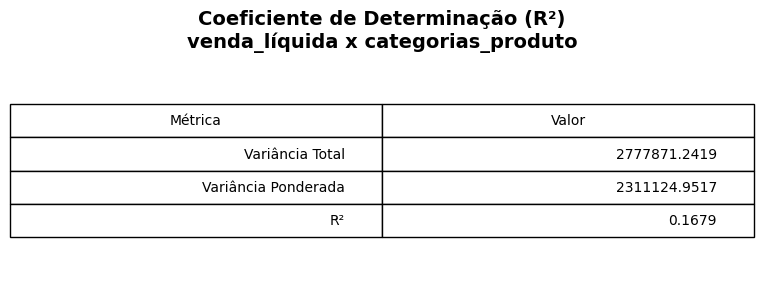

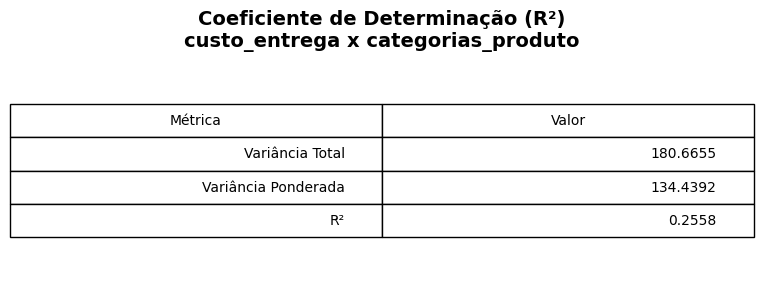

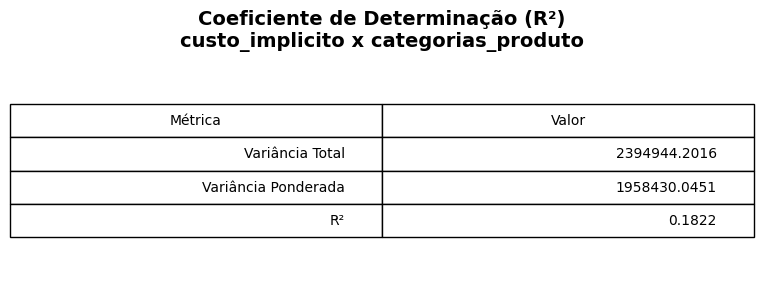

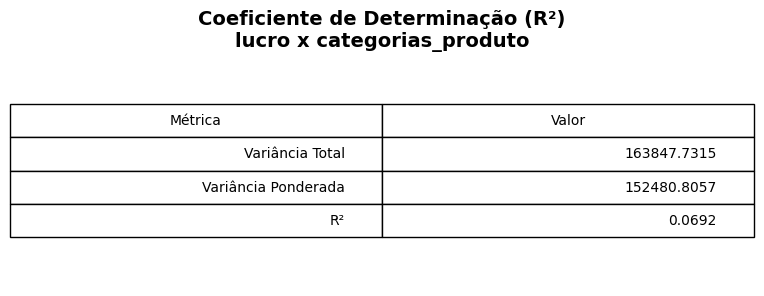

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

x = 'categorias_produto'

quanti =  ['venda_líquida', 'custo_entrega', 'custo_implicito', 'lucro']

df = dados

for y in quanti:


    resultado = coef_determinacao(df, x, y)

    r2 = resultado[0]
    var_total = resultado[1]
    var_ponderada = resultado[2]

    tabela = pd.DataFrame({
        'Métrica': [
            'Variância Total',
            'Variância Ponderada',
            'R²'
        ],
        'Valor': [
            round(var_total, 4),
            round(var_ponderada, 4),
            round(r2, 4)
        ]
    })

    fig, ax = plt.subplots(figsize=(8, 3))

    ax.axis('off')

    ax.set_title(
        f'Coeficiente de Determinação (R²)\n{y} x {x}',
        fontsize=14,
        fontweight='bold'
    )

    tabela_plot = ax.table(
        cellText=tabela.values,
        colLabels=tabela.columns,
        loc='center'
    )

    tabela_plot.auto_set_font_size(False)
    tabela_plot.set_fontsize(10)
    tabela_plot.scale(1.2, 2)

    plt.show()

    plt.close()


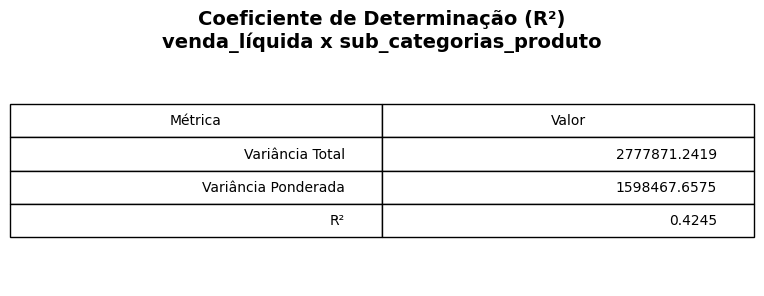

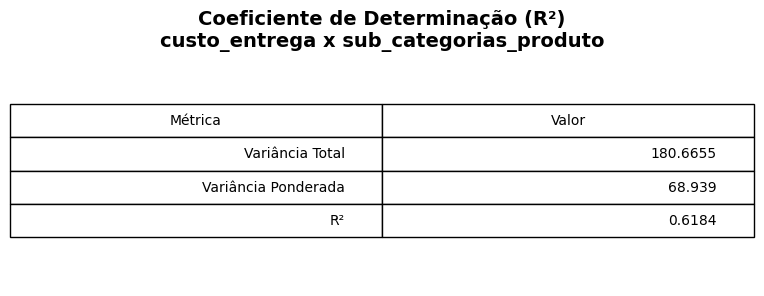

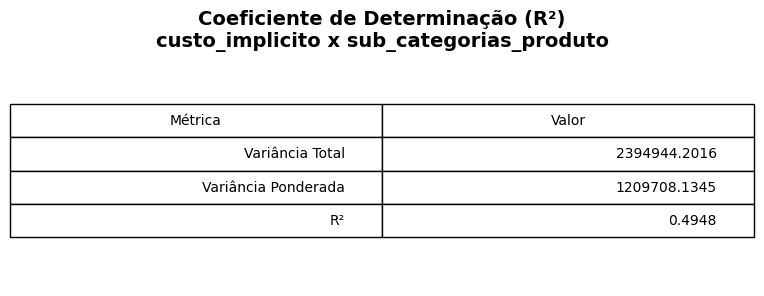

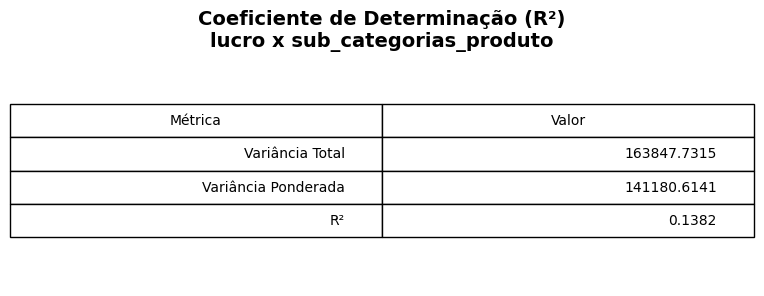

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

x = 'sub_categorias_produto'

quanti =  ['venda_líquida', 'custo_entrega', 'custo_implicito', 'lucro']

df = dados

for y in quanti:


    resultado = coef_determinacao(df, x, y)

    r2 = resultado[0]
    var_total = resultado[1]
    var_ponderada = resultado[2]

    tabela = pd.DataFrame({
        'Métrica': [
            'Variância Total',
            'Variância Ponderada',
            'R²'
        ],
        'Valor': [
            round(var_total, 4),
            round(var_ponderada, 4),
            round(r2, 4)
        ]
    })

    fig, ax = plt.subplots(figsize=(8, 3))

    ax.axis('off')

    ax.set_title(
        f'Coeficiente de Determinação (R²)\n{y} x {x}',
        fontsize=14,
        fontweight='bold'
    )

    tabela_plot = ax.table(
        cellText=tabela.values,
        colLabels=tabela.columns,
        loc='center'
    )

    tabela_plot.auto_set_font_size(False)
    tabela_plot.set_fontsize(10)
    tabela_plot.scale(1.2, 2)

    plt.show()

    plt.close()


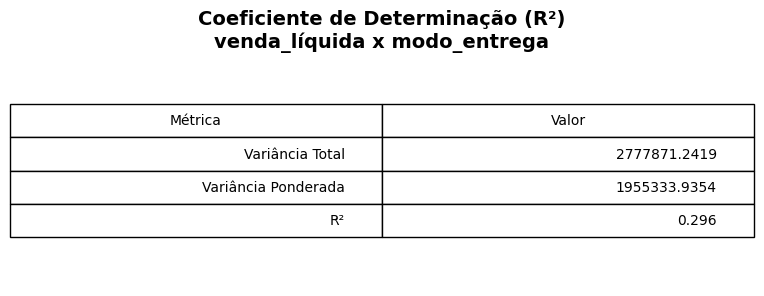

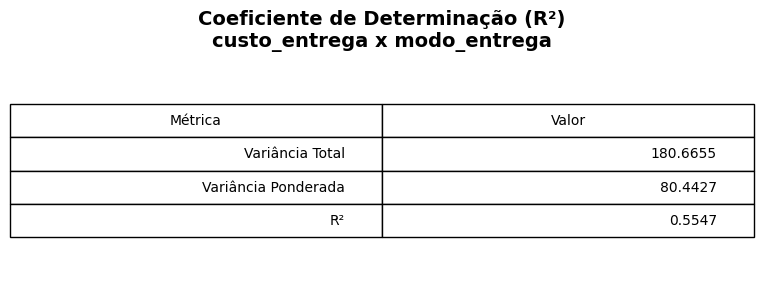

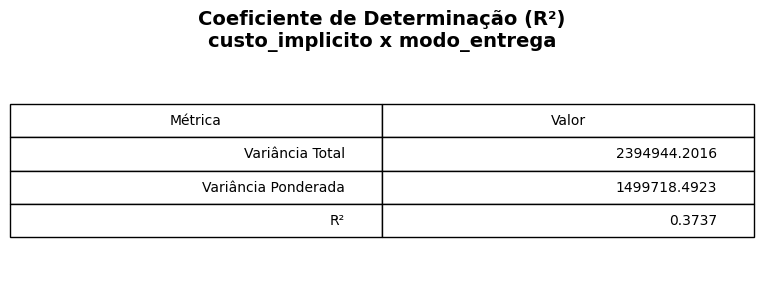

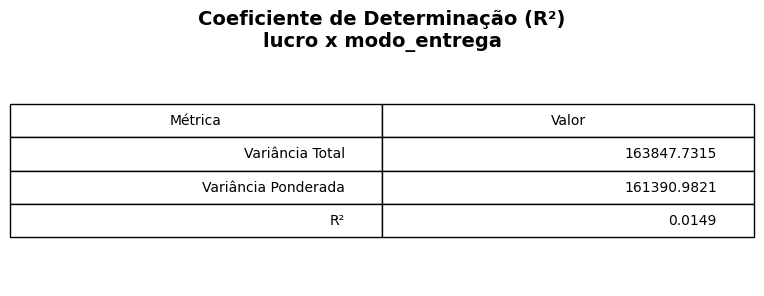

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

x = 'modo_entrega'

quanti =  ['venda_líquida', 'custo_entrega', 'custo_implicito', 'lucro']

df = dados


for y in quanti:


    resultado = coef_determinacao(df, x, y)

    r2 = resultado[0]
    var_total = resultado[1]
    var_ponderada = resultado[2]

    tabela = pd.DataFrame({
        'Métrica': [
            'Variância Total',
            'Variância Ponderada',
            'R²'
        ],
        'Valor': [
            round(var_total, 4),
            round(var_ponderada, 4),
            round(r2, 4)
        ]
    })

    fig, ax = plt.subplots(figsize=(8, 3))

    ax.axis('off')

    ax.set_title(
        f'Coeficiente de Determinação (R²)\n{y} x {x}',
        fontsize=14,
        fontweight='bold'
    )

    tabela_plot = ax.table(
        cellText=tabela.values,
        colLabels=tabela.columns,
        loc='center'
    )

    tabela_plot.auto_set_font_size(False)
    tabela_plot.set_fontsize(10)
    tabela_plot.scale(1.2, 2)

    plt.show()

    plt.close()
